# Ejercicio 3

Utilizando modelos de lenguaje en pyTerrier repita los experimentos del ejercicio 7 del TP de ”modelos” y compare los resultados con los anteriores. ¿Son consistentes? Calcule las métricas apropiadas para comparar los diferentes sistemas y configuraciones.

## 0. Recordando Ejercicio 7 TP Modelos



Utilizando la colección de prueba Vaswani y pyTerrier se debe realizar la evaluación del sistema. Para ello, es necesario construir un índice con los documentos de la colección y luego ejecutar las consultas (modelo vectorial con TF/IDF), las cuales deben armar a partir de los términos que considere de las necesidades de información (puede eliminar las palabras vacías). Los resultados deben ser comparados contra los juicios de relevancia de la colección. Realizar el análisis en dos ámbitos:

a)	Global (promedio de todas la consultas), para las siguientes métricas: P@10, AP, NDCG@10 e incluya la gráfica de R–P en los 11 puntos estándar. 

b)	Individual (por query), para las mismas métricas, calculando la distribución de los valores en cada caso.


## 1. Inicializacion PyTerrier

In [40]:
import pandas as pd
import pyterrier as pt
import os
if not pt.java.started():
  pt.java.init()

## 2. Indexacion

In [41]:
files = pt.io.find_files("../Colecciones/vaswani/")

#Crear el indexador - Ruta absoluta
index_path = os.path.abspath("index_vaswani")

# Crear carpeta si no existe
os.makedirs(index_path, exist_ok=True)

print("Index path:", index_path)

indexer = pt.TRECCollectionIndexer(index_path, overwrite=True, verbose=True)

indexref = indexer.index(files) 

Index path: c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP3\EJ3\index_vaswani


  0%|          | 0/16 [00:00<?, ?files/s]

03:04:08.913 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/corpus\.complete. Perhaps trec.collection.class is wrongly set, TrecDocTags are incorrect, or decompression failed
03:04:11.187 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/index\terrier_stemmed\.complete. Perhaps trec.collection.class is wrongly set, TrecDocTags are incorrect, or decompression failed
03:04:11.193 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/index\terrier_stemmed\data.direct.bf. Perhaps trec.collection.class is wrongly set, TrecDocTags are incorrect, or decompression failed
03:04:11.198 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/index\terrier_stemmed\data.document.fsarrayfile. Perhaps trec.collection

17files [00:02,  7.04files/s]            

03:04:11.447 [main] ERROR org.terrier.structures.indexing.Indexer -- Could not rename index
java.io.IOException: Rename of index structure file 'c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP3\EJ3\index_vaswani/data_1.direct.bf' (exists) to 'c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP3\EJ3\index_vaswani/data.direct.bf' (exists) failed - likely that source file is still open. Possible indexing bug?
	at org.terrier.structures.IndexUtil.renameIndex(IndexUtil.java:379)
	at org.terrier.structures.indexing.Indexer.index(Indexer.java:388)


17files [00:02,  6.49files/s]


## 2.1 Indice

In [42]:
index = pt.IndexFactory.of(indexref)

print("------ MI INDICE ------")
print(index.collectionStatistics)

------ MI INDICE ------
Number of documents: 11429
Number of terms: 7756
Number of postings: 224573
Number of fields: 0
Number of tokens: 271581
Field names: []
Positions:   false



## 3. Modelos

### 3.1 TF-IDF (usado en TP anterior)

In [43]:
tfidf = pt.terrier.Retriever(index, wmodel="TF_IDF")

## 3.2 Jelinek-Mercer

In [45]:
#jm = pt.BatchRetrieve(index, wmodel="JelinekMercer")
#jm = pt.terrier.Retriever(index, wmodel="JM", controls={"jm.lambda": 0.7})
jm = pt.terrier.Retriever(index, wmodel="Hiemstra_LM", controls={"c": 0.7})

### 3.3 Dirichlet Prior

In [46]:
dirichlet = pt.terrier.Retriever(index, wmodel="DirichletLM", controls={"dirichlet.mu": 1000})

## 4. Necesidad de Informacion

In [49]:
import pandas as pd
import re

# Parseo de la query de la coleccion
def parse_queries(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    queries = []

    tops = content.split("<top>")

    for top in tops:
        if "<num>" in top:
            # Obtener qid
            qid = re.search(r"<num>(\d+)</num>", top)
            qid = qid.group(1) if qid else None

            # Obtener query
            title = re.search(r"<title>(.*?)</title>", top, re.DOTALL)
            query = title.group(1).strip() if title else ""

            queries.append([qid, query])

    return pd.DataFrame(queries, columns=["qid", "query"])


topics = parse_queries("../Colecciones/vaswani/query-text.trec")
topics["qid"] = topics["qid"].astype(str)

topics

,qid,query
0,1,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
1,2,MATHEMATICAL ANALYSIS AND DESIGN DETAILS OF WA...
2,3,USE OF DIGITAL COMPUTERS IN THE DESIGN OF BAND...
3,4,SYSTEMS OF DATA CODING FOR INFORMATION TRANSFER
4,5,USE OF PROGRAMS IN ENGINEERING TESTING OF COMP...
...,...,...
88,89,TUNNEL DIODE CONSTRUCTION AND ITS ELECTRICAL C...
89,90,ELECTRONIC DENSITY OF STATES AT THE SURFACE OF...
90,91,RESISTIVITY OF METALLIC THIN FILMS RELATED TO ...
91,92,THE PHENOMENON OF RADIATION CAUSED BY CHARGED ...


## 5. Juicios de Relevancia

In [50]:
qrels = pd.read_csv(
    "../Colecciones/vaswani/qrels",
    delim_whitespace=True,
    names=["qid", "unused", "docno", "label"]
)

qrels = qrels[["qid", "docno", "label"]]
qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)
qrels["label"] = qrels["label"].astype(int)

qrels

C:\Users\Leone\AppData\Local\Temp\ipykernel_18116\3360858100.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  qrels = pd.read_csv(


,qid,docno,label
0,1,1239,1
1,1,1502,1
2,1,4462,1
3,1,4569,1
4,1,5472,1
...,...,...,...
2078,93,9875,1
2079,93,9956,1
2080,93,10497,1
2081,93,11191,1


## 6. Evaluacion

In [68]:
from pyterrier.measures import *

### 6.1 Evaluacion global

In [78]:
metrics = ["P_10", "map", "ndcg_cut_10"]

pt.Experiment(
    [tfidf,jm,dirichlet],
    topics,
    qrels,
    eval_metrics=metrics,
    names=["TF-IDF", "Jelinek-Mercer", "Dirichlet-Priors"]
)

,name,map,P_10,ndcg_cut_10
0,TF-IDF,0.290905,0.359140,0.444411
1,Jelinek-Mercer,0.253518,0.321505,0.394723
2,Dirichlet-Priors,0.196005,0.239785,0.297378


### 6.2 Curva R-P

Modelo: TF-IDF
Recall: 0.0, Precision: 0.7254
Recall: 0.1, Precision: 0.6405
Recall: 0.2, Precision: 0.5208
Recall: 0.3, Precision: 0.4064
Recall: 0.4, Precision: 0.3362
Recall: 0.5, Precision: 0.2679
Recall: 0.6, Precision: 0.1978
Recall: 0.7, Precision: 0.1512
Recall: 0.8, Precision: 0.1042
Recall: 0.9, Precision: 0.0575
Recall: 1.0, Precision: 0.0240
Modelo: Jelinek-Mercer
Recall: 0.0, Precision: 0.6779
Recall: 0.1, Precision: 0.5603
Recall: 0.2, Precision: 0.4541
Recall: 0.3, Precision: 0.3600
Recall: 0.4, Precision: 0.2955
Recall: 0.5, Precision: 0.2328
Recall: 0.6, Precision: 0.1703
Recall: 0.7, Precision: 0.1246
Recall: 0.8, Precision: 0.0851
Recall: 0.9, Precision: 0.0489
Recall: 1.0, Precision: 0.0197
Modelo: Dirichlet-Priors
Recall: 0.0, Precision: 0.5754
Recall: 0.1, Precision: 0.4245
Recall: 0.2, Precision: 0.3257
Recall: 0.3, Precision: 0.2581
Recall: 0.4, Precision: 0.2150
Recall: 0.5, Precision: 0.1731
Recall: 0.6, Precision: 0.1381
Recall: 0.7, Precision: 0.1100
Recall:

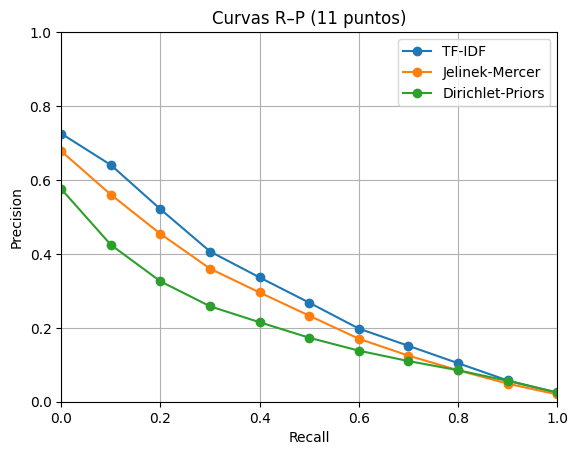

In [82]:
res = pt.Experiment(
    [tfidf,jm,dirichlet],
    topics,
    qrels,
    eval_metrics=["iprec_at_recall"],
    names=["TF-IDF", "Jelinek-Mercer", "Dirichlet-Priors"]
)
#print(res)

import matplotlib.pyplot as plt


recall_levels  = [i/10 for i in range(11)]

plt.figure()

for i, model_name in enumerate(res["name"]):
    precision = [
        res.iloc[i][f"IPrec@{r:.1f}"] for r in recall_levels
    ]
    print(f"Modelo: {model_name}")
    for r, p in zip(recall_levels, precision):
      print(f"Recall: {r:.1f}, Precision: {p:.4f}")
    
    plt.plot(recall_levels, precision, marker='o', label=model_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas R–P (11 puntos)")
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

### 6.3 Evaluacion individual por query

In [71]:
por_query = pt.Experiment(
    [tfidf,jm,dirichlet],
    topics,
    qrels,
    eval_metrics=["P_10", "map", "ndcg_cut_10"],
    perquery=True,
    names=["TF-IDF", "Jelinek-Mercer", "Dirichlet-Priors"]
)

por_query

,name,qid,measure,value
558,Dirichlet-Priors,1,map,0.224278
559,Dirichlet-Priors,1,P_10,0.400000
560,Dirichlet-Priors,1,ndcg_cut_10,0.510716
585,Dirichlet-Priors,10,map,0.140551
586,Dirichlet-Priors,10,P_10,0.200000
...,...,...,...,...
274,TF-IDF,92,P_10,0.200000
275,TF-IDF,92,ndcg_cut_10,0.179931
276,TF-IDF,93,map,0.230467
277,TF-IDF,93,P_10,0.300000


In [72]:
tfidf_q = por_query[por_query["name"] == "TF-IDF"]
jm_q = por_query[por_query["name"] == "Jelinek-Mercer"]
dir_q = por_query[por_query["name"] == "Dirichlet-Priors"]

In [89]:
# Pivot por cada modelo
tfidf_w = tfidf_q.pivot(index="qid", columns="measure", values="value")
jm_w = jm_q.pivot(index="qid", columns="measure", values="value")
dir_w = dir_q.pivot(index="qid", columns="measure", values="value")

modelos = [tfidf_w,jm_w,dir_w]
nombre = ["TF-IDF","JM","Dirichlet"]

#### 6.3.1 Histogramas comparativos

#### 6.3.1.1 P@10

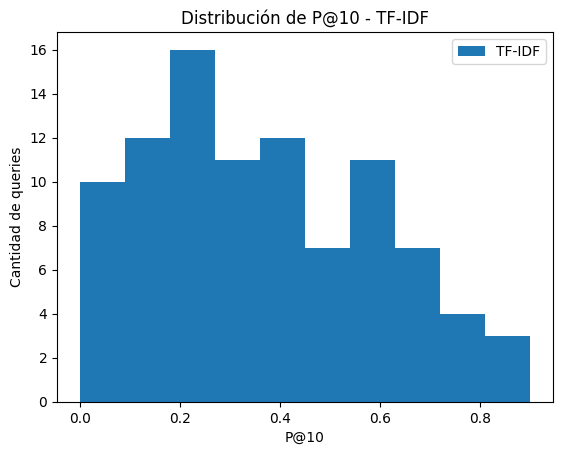

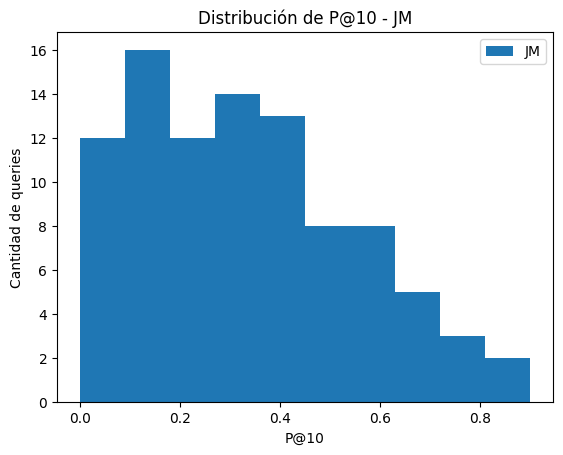

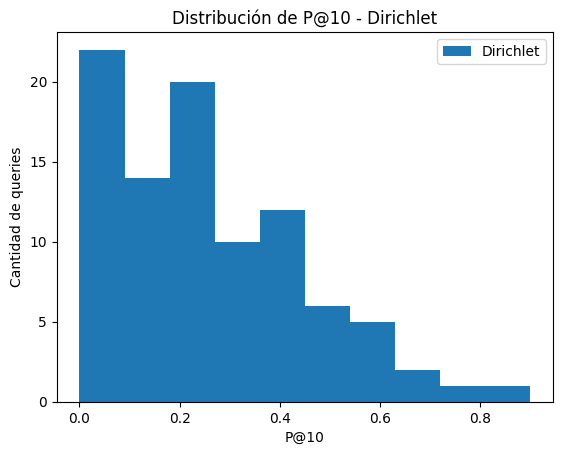

In [95]:
for i, modelo in enumerate(modelos):
  plt.hist(modelo["P_10"], alpha=1, label=nombre[i])

  plt.xlabel("P@10")
  plt.ylabel("Cantidad de queries")
  plt.title(f"Distribución de P@10 - {nombre[i]}")
  plt.legend()
  plt.show()


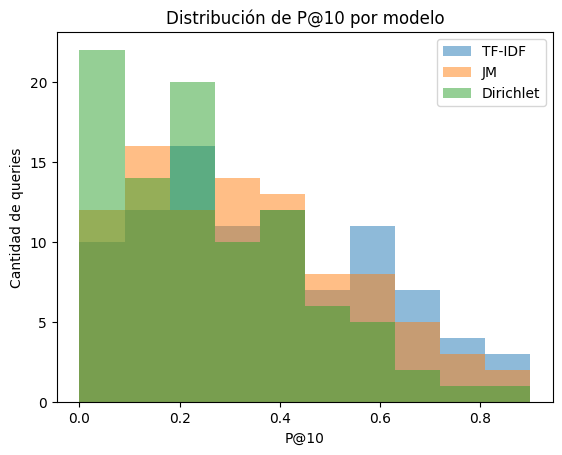

In [96]:
import matplotlib.pyplot as plt

plt.hist(tfidf_w["P_10"], alpha=0.5, label="TF-IDF")
plt.hist(jm_w["P_10"], alpha=0.5, label="JM")
plt.hist(dir_w["P_10"], alpha=0.5, label="Dirichlet")

plt.xlabel("P@10")
plt.ylabel("Cantidad de queries")
plt.title("Distribución de P@10 por modelo")
plt.legend()
plt.show()


#### 6.3.1.2 MAP

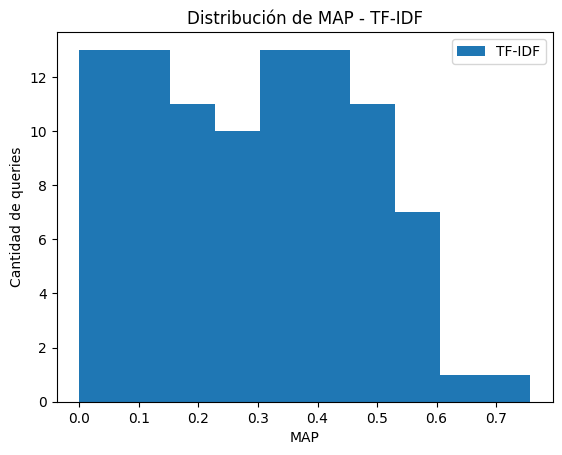

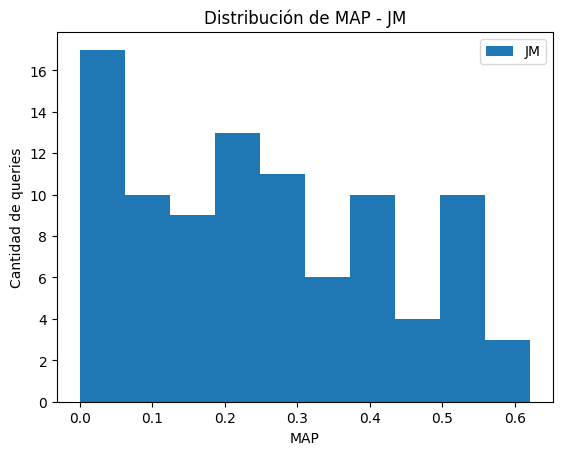

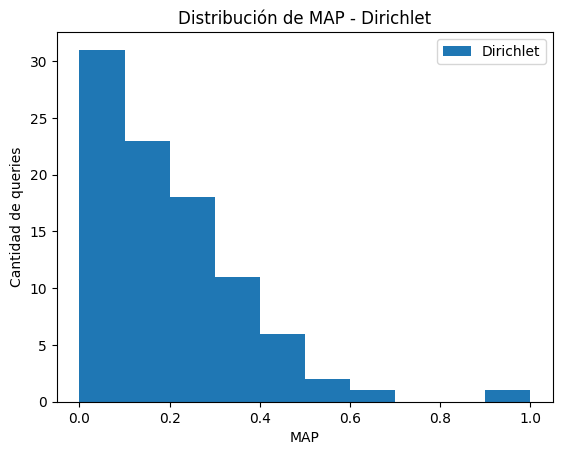

In [97]:
for i, modelo in enumerate(modelos):
  plt.hist(modelo["map"], alpha=1, label=nombre[i])

  plt.xlabel("MAP")
  plt.ylabel("Cantidad de queries")
  plt.title(f"Distribución de MAP - {nombre[i]}")
  plt.legend()
  plt.show()

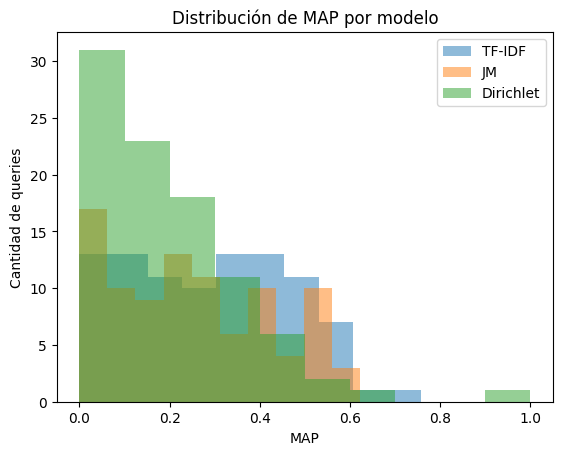

In [76]:
plt.hist(tfidf_w["map"], alpha=0.5, label="TF-IDF")
plt.hist(jm_w["map"], alpha=0.5, label="JM")
plt.hist(dir_w["map"], alpha=0.5, label="Dirichlet")

plt.xlabel("MAP")
plt.ylabel("Cantidad de queries")
plt.title("Distribución de MAP por modelo")
plt.legend()
plt.show()

#### 6.3.1.2 NDCG@10

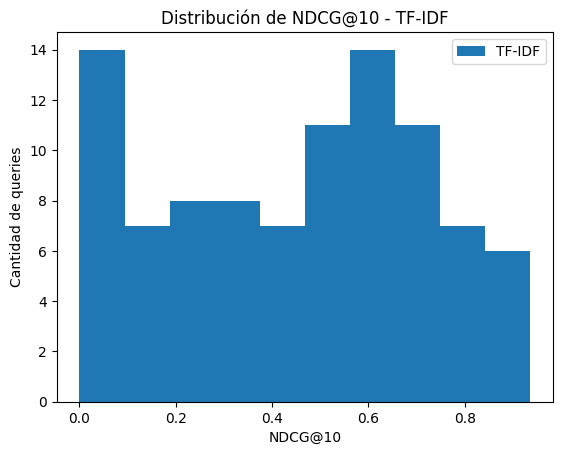

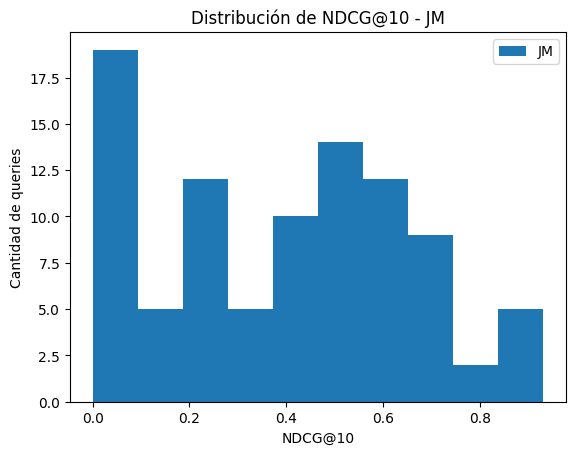

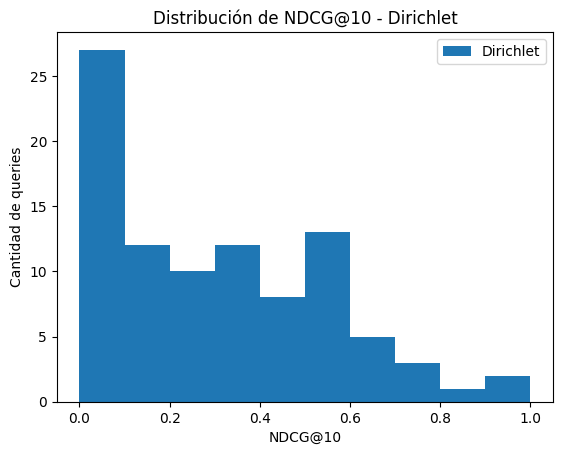

In [98]:
for i, modelo in enumerate(modelos):
  plt.hist(modelo["ndcg_cut_10"], alpha=1, label=nombre[i])

  plt.xlabel("NDCG@10")
  plt.ylabel("Cantidad de queries")
  plt.title(f"Distribución de NDCG@10 - {nombre[i]}")
  plt.legend()
  plt.show()

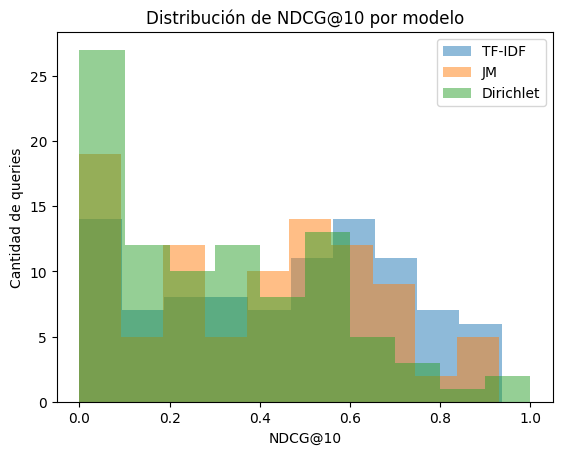

In [75]:
plt.hist(tfidf_w["ndcg_cut_10"], alpha=0.5, label="TF-IDF")
plt.hist(jm_w["ndcg_cut_10"], alpha=0.5, label="JM")
plt.hist(dir_w["ndcg_cut_10"], alpha=0.5, label="Dirichlet")

plt.xlabel("NDCG@10")
plt.ylabel("Cantidad de queries")
plt.title("Distribución de NDCG@10 por modelo")
plt.legend()
plt.show()